<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [196]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

### Configuración de ejecución

Con `TRAIN_MODELS = True`, se reentrenarán las diferentes arquitecturas. En el caso `TRAIN_MODELS = False` se omite y se recomieda dejarlo así para evaluar, ya que el entrenamiento duraría algunas horas. Ya se encuentra un modelo para cada arquitectura, entrenados en ejecuciones anteriores, dentro de la carpeta `Desafios\resolucion_3_models`. Esta carpeta se agrega intencionalmente al repositorio para poder ejecutar el notebook completo y obtener distintas secuencias con cada modelo. Si se reentrena, estos serán reemplazados por los nuevos.

Con `SHOW_GRADIO = True`, se mostrará la interfaz de *Gradio* al llegar a la celda correspondiente, sino se omite y se termina de ejecutar el notebook. Se configura aquí para que no detenga la ejecución si el notebook se corre completo.

In [197]:
TRAIN_MODELS = False
histories = {}
SHOW_GRADIO = False

### Datos

In [198]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de Gutenberg
import re

In [199]:
import urllib.request
import re

# Abrir la url y leer los bytes
raw_html_response = urllib.request.urlopen('https://www.gutenberg.org/files/2554/2554-0.txt')
raw_bytes = raw_html_response.read()

# Decodificar los bytes a un string
raw_text = raw_bytes.decode('utf-8')

# Extraer el contenido del libro, excluyendo el header y el footer de Project Gutenberg
# El regex tiene que ser preciso para el formato específico de Gutenberg. Los marcadores son:
# *** START OF THE PROJECT GUTENBERG EBOOK CRIME AND PUNISHMENT ***
# ... contenido ...
# *** END OF THE PROJECT GUTENBERG EBOOK CRIME AND PUNISHMENT ***
match = re.search(r'\*\*\* START OF THE PROJECT GUTENBERG EBOOK.+? \*\*\*(.+?)\*\*\* END OF THE PROJECT GUTENBERG EBOOK.+? \*\*\*', raw_text, re.DOTALL)

if match:
    book_text = match.group(1).strip()
else:
    # Usar el texto completo crudo si no se encontraron los marcadores.
    book_text = raw_text

# Reemplazar por un espacio a todos los saltos de líneas no precedidos por un punto,
# con el objetivo de limpiar el exceso de caracteres \n.
book_text = re.sub(r'(?<!\.)\n', ' ', book_text)

book_text = book_text.lower()

In [200]:
# Se utiliza solo la mitad del libro. En los primeros intentos, los
# entrenamientos fueron interrumpidos porque se llenó la RAM del Colab
book_text = book_text[:len(book_text)//2]
len(book_text)

567554

In [201]:
# en book text se encuentra el texto de todo el libro
book_text[:1000]

'crime and punishment  by fyodor dostoevsky    translated by constance garnett     translator’s preface  a few words about dostoevsky himself may help the english reader to understand his work.\n dostoevsky was the son of a doctor. his parents were very hard-working and deeply religious people, but so poor that they lived with their five children in only two rooms. the father and mother spent their evenings in reading aloud to their children, generally from books of a serious character.\n though always sickly and delicate dostoevsky came out third in the final examination of the petersburg school of engineering. there he had already begun his first work, “poor folk.”  this story was published by the poet nekrassov in his review and was received with acclamations. the shy, unknown youth found himself instantly something of a celebrity. a brilliant and successful career seemed to open before him, but those hopes were soon dashed. in 1849 he was arrested.\n though neither by temperament n

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_23036\597833466.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


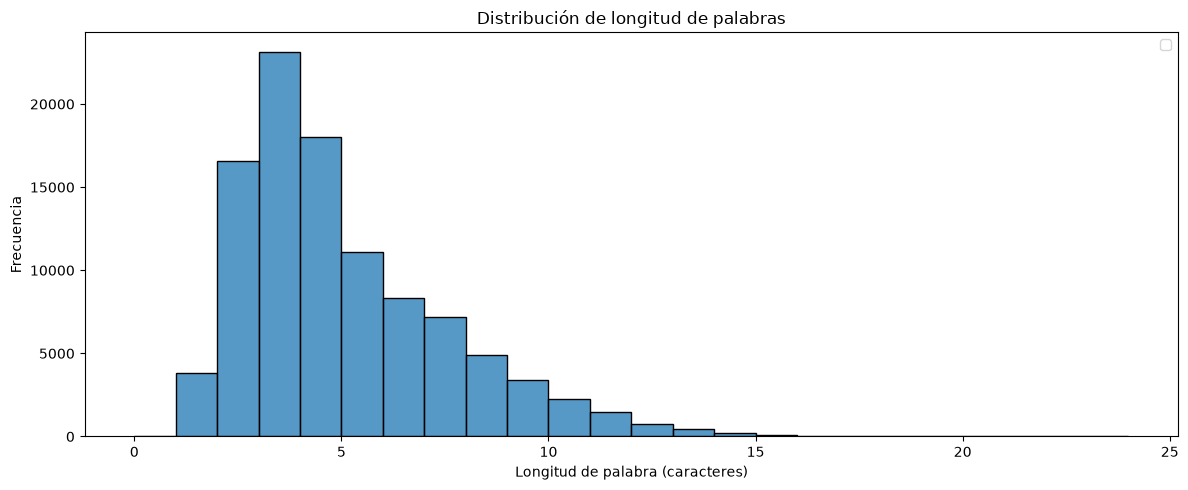

Longitud promedio: 4.56 caracteres
Longitud mediana: 4.00 caracteres
Percentil 95: 10.00 caracteres


In [202]:
import seaborn as sns
import matplotlib.pyplot as plt

words = book_text.split()
word_lengths = [len(word) for word in words]

plt.figure(figsize=(12, 5))
sns.histplot(word_lengths, bins=range(0, max(word_lengths)+2))
plt.title('Distribución de longitud de palabras')
plt.xlabel('Longitud de palabra (caracteres)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Longitud promedio: {np.mean(word_lengths):.2f} caracteres")
print(f"Longitud mediana: {np.median(word_lengths):.2f} caracteres")
print(f"Percentil 95: {np.percentile(word_lengths, 95):.2f} caracteres")

In [203]:
# Se considera que un contexto de 50 caracteres es apropiado
max_context_size = 50

In [204]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [205]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(book_text)

In [206]:
# Veamos los caracteres que aparecen
chars_vocab

{'\n',
 ' ',
 '!',
 '(',
 ')',
 '*',
 ',',
 '-',
 '.',
 '0',
 '1',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 ':',
 ';',
 '?',
 '[',
 ']',
 '_',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 'é',
 'ê',
 'î',
 'ï',
 'ô',
 '‘',
 '’',
 '“',
 '”'}

In [207]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

59

In [208]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
# Al probar modelos guardados habiendo reiniciado el kernel, se obtuvieron incoherencias
# porque estos diccionarios no fueron iguales en cada nueva ejecución. Entonces, se ordenan
# los caracteres en el texto del libro para que los indices apunten correctamente.
# No sé si es una completa garantía, se debería guardar el diccionario prerentemente.

sorted_vocab = sorted(chars_vocab)

# char2idx = {k: v for v,k in enumerate(sorted_vocab)}
# idx2char = {v: k for v,k in char2idx.items()}
char2idx = {k: v for v, k in enumerate(sorted_vocab)}  # carácter -> índice
idx2char = {v: k for v, k in enumerate(sorted_vocab)}  # índice -> carácter


###  Tokenizar

In [209]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in book_text]

In [253]:
tokenized_text[:100]

[26,
 41,
 32,
 36,
 28,
 1,
 24,
 37,
 27,
 1,
 39,
 44,
 37,
 32,
 42,
 31,
 36,
 28,
 37,
 43,
 1,
 1,
 25,
 48,
 1,
 29,
 48,
 38,
 27,
 38,
 41,
 1,
 27,
 38,
 42,
 43,
 38,
 28,
 45,
 42,
 34,
 48,
 1,
 1,
 1,
 1,
 43,
 41,
 24,
 37,
 42,
 35,
 24,
 43,
 28,
 27,
 1,
 25,
 48,
 1,
 26,
 38,
 37,
 42,
 43,
 24,
 37,
 26,
 28,
 1,
 30,
 24,
 41,
 37,
 28,
 43,
 43,
 1,
 1,
 1,
 1,
 1,
 43,
 41,
 24,
 37,
 42,
 35,
 24,
 43,
 38,
 41,
 56,
 42,
 1,
 39,
 41,
 28,
 29,
 24]

### Organizando y estructurando el dataset

In [211]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.2
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [212]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [213]:
# La línea del notebook produce que cada elemento de tokenized_sentences_val tenga una longitud creciente
# produciendo entonces una lista de elementos con distinta longitud. Se reemplaza.
# En retrospectiva, esta podría ser la causa de por qué en el primer intento con una SimpleRNN, la perplejidad
# subía en cada nueva epoch en vez de bajar.

# tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]
tokenized_sentences_val = [val_text[init*max_context_size:(init+1)*(max_context_size)] for init in range(num_val)]

In [214]:
[len(seq) for seq in tokenized_sentences_val][5]

50

In [215]:
# Se agrega un stride porque se interrumpe la ejecución debido a que se llenaba la RAM. Con el stride, deberían haber menos secuencias.
# Se termina dejando el stride en 1 y reduciendo el corpus
stride = 1
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(0, len(train_text)-max_context_size+1, stride)]

In [216]:
X = np.array(tokenized_sentences_train[:-1]) # Todos menos el último
y = np.array(tokenized_sentences_train[1:]) # Todos menos el primero

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [217]:
X.shape

(453954, 50)

In [218]:
X[0,:10]

array([26, 41, 32, 36, 28,  1, 24, 37, 27,  1])

In [219]:
y[0,:10]

array([41, 32, 36, 28,  1, 24, 37, 27,  1, 39])

In [220]:
vocab_size = len(chars_vocab)

# Definiendo los modelos

## SimpleRNN (Base Model)

In [221]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [222]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

c:\CEIA\4CuartoBimestre\NLP1\procesamiento_lenguaje_natural_ceia\.venv\Lib\site-packages\keras\src\layers\core\wrapper.py:25: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_4              │ (None, None, 59)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, None, 200)      │        52,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, None, 59)       │        11,859 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,859 (249.45 KB)

 Trainable params: 63,859 (249.45 KB)

 Non-trainable params: 0 (0.00 B)


### Definir el modelo

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [223]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl, model_name, patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience
      self.model_name = model_name

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save(f"{self.model_name}.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


### Entrenamiento

In [224]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
if TRAIN_MODELS:
    history_ppl = []
    hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl,"base_model")], batch_size=256)
    histories["SimpleRNN"] = history_ppl

In [225]:
import matplotlib.pyplot as plt
import seaborn as sns
if TRAIN_MODELS:
    # Entrenamiento
    epoch_count = range(1, len(history_ppl) + 1)
    sns.lineplot(x=epoch_count,  y=history_ppl)
    plt.show()

El entrenamiento transcurrió las 20 épocas, demorando unos 427 segundos.

## LSTM Simple
Se define una nueva arquitectura para la red usando una capa LSTM y regularización con Dropout (interno y externo). Se mantiene la capa densa al final.

In [226]:
from keras.layers import LSTM, Dropout

In [227]:
model_lstm = Sequential()
model_lstm.add(
    TimeDistributed(
        CategoryEncoding(
            num_tokens=vocab_size, output_mode="one_hot"
        ),
        input_shape=(None, 1)
    )
)
model_lstm.add(
    LSTM(
        128,
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(vocab_size, activation='softmax'))
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model_lstm.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_5              │ (None, None, 59)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, None, 128)      │        96,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, None, 59)       │         7,611 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,867 (405.73 KB)

 Trainable params: 103,867 (405.73 KB)

 Non-trainable params: 0 (0.00 B)

In [228]:
if TRAIN_MODELS:
    history_ppl = [] # Se resetea el historial
    hist = model_lstm.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl,"simple_lstm_model")], batch_size=256)
    histories["SimpleLSTM"] = history_ppl

In [229]:
if TRAIN_MODELS:
    # Entrenamiento
    epoch_count = range(1, len(history_ppl) + 1)
    sns.lineplot(x=epoch_count,  y=history_ppl)
    plt.show()

## LSTM apilado
Se propone un modelo con dos capas LSTM apiladas, más chicas que la del modelo anterior. Además se prueba también con usar Embedding en vez de TimeDistributed con CategoryEncoding. Se mantiene el uso de regularización mediante Dropout.

In [230]:
from keras.layers import Embedding

In [231]:
model_lstm_2 = Sequential()
model_lstm_2.add(
    Embedding(
        input_dim=vocab_size+1,
        output_dim=50,
        input_shape=(max_context_size,)
      )
)
model_lstm_2.add(
    LSTM(
        64,
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)
model_lstm_2.add(Dropout(0.2))
model_lstm_2.add(LSTM(64, return_sequences=True))
model_lstm_2.add(Dense(32, activation='relu'))
model_lstm_2.add(Dense(vocab_size, activation='softmax'))
model_lstm_2.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model_lstm_2.summary()

c:\CEIA\4CuartoBimestre\NLP1\procesamiento_lenguaje_natural_ceia\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:126: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 50, 50)         │         3,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50, 64)         │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 50, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 50, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 50, 59)         │         1,947 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,491 (271.45 KB)

 Trainable params: 69,491 (271.45 KB)

 Non-trainable params: 0 (0.00 B)

In [232]:
if TRAIN_MODELS:
    history_ppl = [] # Se resetea el historial
    hist = model_lstm_2.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl,"stacked_lstm_model")], batch_size=256)
    histories["StackedLSTM"] = history_ppl

In [233]:
if TRAIN_MODELS:
    # Entrenamiento
    epoch_count = range(1, len(history_ppl) + 1)
    sns.lineplot(x=epoch_count,  y=history_ppl)
    plt.show()

## GRU apilado
Se hace lo mismo que en el modelo anterior pero con capas de GRU. Se mantiene Embedding y Dropout.

In [234]:
from keras.layers import GRU

In [235]:
model_gru = Sequential()
model_gru.add(
    Embedding(vocab_size+1, 64, input_shape=(max_context_size,))
)
model_gru.add(
    GRU(
        128,
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)
model_gru.add(Dropout(0.2))
model_gru.add(GRU(64, return_sequences=True))
model_gru.add(Dense(vocab_size, activation='softmax'))
model_gru.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model_gru.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 50, 64)         │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 50, 128)        │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 50, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 50, 59)         │         3,835 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,419 (466.48 KB)

 Trainable params: 119,419 (466.48 KB)

 Non-trainable params: 0 (0.00 B)

In [236]:
if TRAIN_MODELS:
    history_ppl = [] # Se resetea el historial
    hist = model_gru.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl,"stacked_gru_model")], batch_size=256)
    histories["StackedGRU"] = history_ppl

In [237]:
if TRAIN_MODELS:
    # Entrenamiento
    epoch_count = range(1, len(history_ppl) + 1)
    sns.lineplot(x=epoch_count,  y=history_ppl)
    plt.show()

### Predicción del próximo caracter

Seleccionar el modelo que se desea evaluar.

In [238]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia en Gradio
# model = keras.models.load_model('resolucion_3_models/base_model.keras')
# model = keras.models.load_model('resolucion_3_models/simple_lstm_model.keras')
# model = keras.models.load_model('resolucion_3_models/stacked_lstm_model.keras')
model = keras.models.load_model('resolucion_3_models/stacked_gru_model.keras')

In [239]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

# !pip install -q gradio

In [240]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word

if SHOW_GRADIO:
    iface = gr.Interface(
        fn=model_response,
        inputs=["textbox"],
        outputs="text")

    iface.launch(debug=True)

### Generación de secuencias

In [241]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [242]:
input_text='it'

generate_seq(model, input_text, max_length=max_context_size, n_words=50)

'it was a strange and strange and strange and strange'

###  Beam search y muestreo aleatorio

In [ ]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx.get(ch, char2idx[' ']) for ch in text] # Se usa espacio como fallback
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [244]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [245]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=60,input="your friend has", temp=2.0, mode='sto')

In [246]:
salidas[0]

array([48, 38, 44, 41,  1, 29, 41, 32, 28, 37, 27,  1, 31, 24, 42,  1, 31,
       24, 27,  1, 37, 38, 43,  1, 46, 32, 35, 35,  1, 33, 44, 42, 43,  1,
       43, 31, 28,  1, 39, 38, 26, 34, 28, 43,  1, 24, 37, 27,  1, 42, 43,
       24, 37, 27, 32, 37, 30,  8,  1, 43, 31, 28,  1, 35, 24, 42, 43,  1,
       35, 32, 34, 28,  1, 43, 38])

In [247]:
# veamos las salidas
decode(salidas[0])

'your friend has had not will just the pocket and standing. the last like to'

### Comparación de modelos

In [248]:
import os
import time

In [ ]:
# Se generan distintas secuencias para cada uno de los modelos usando ambos
# modos y distintas temperaturas en el estocástico.

model_folder_path = r"resolucion_3_models"
if not os.path.isdir(model_folder_path):
    raise FileNotFoundError(f"Folder not found: {model_folder_path}")

models = {}
evals = [
    {"mode": "det", "temp": 1.0, "num_words": 50, "text": ""}, # Se deja temp para evitar un error de missing key
    {"mode": "det", "temp": 1.0, "num_words": 50, "text": "the young man"},
    {"mode": "sto", "temp": 1.0, "num_words": 50, "text": ""},
    {"mode": "sto", "temp": 1.0, "num_words": 50, "text": "the young man"},
    {"mode": "sto", "temp": 2.5, "num_words": 50, "text": ""},
    {"mode": "sto", "temp": 2.5, "num_words": 50, "text": "the young man"},
    {"mode": "sto", "temp": 1.5, "num_words": 100, "text": ""},
]
for item in os.listdir(model_folder_path):
    item_path = os.path.join(model_folder_path, item)

    model_name = item.replace(".keras", "")

    loaded_model = keras.models.load_model(item_path)

    # Set de evaluaciones
    print(f"Modelo: {model_name.upper()} ===============================")
    for eval in evals:
        if eval["mode"] == "det":
            eval_type = "Determinística"
        else:
            eval_type = f"Estocástica - Temp {eval["temp"]}"
        print(f" - Evaluación {eval_type} - Seed: '{eval["text"]}'")
        start_time = time.perf_counter()
        salidas = beam_search(loaded_model,num_beams=10,num_words=eval['num_words'],input=eval['text'], temp=eval['temp'], mode=eval['mode'])
        end_time = time.perf_counter()

        print(f"    Resultado: {decode(salidas[0])}")
        print(f"    Tiempo: {end_time - start_time:.6f}s")


Modelo: BASE_MODEL ===============================
 - Evaluación Determinística - Seed: ''
    Resultado: “what do you would have been out of the old woman 
    Tiempo: 34.206646s
 - Evaluación Determinística - Seed: 'the young man'
    Resultado: the young man of the police of himself, and he had been in the 
    Tiempo: 31.690260s
 - Evaluación Estocástica - Temp 1.0 - Seed: ''
    Resultado: “you are you are you are you understand it all the
    Tiempo: 31.611990s
 - Evaluación Estocástica - Temp 1.0 - Seed: 'the young man'
    Resultado: the young man was something in the words at the sound him to se
    Tiempo: 31.695840s
 - Evaluación Estocástica - Temp 2.5 - Seed: ''
    Resultado: as it all, shouted and do you all of might them af
    Tiempo: 31.780551s
 - Evaluación Estocástica - Temp 2.5 - Seed: 'the young man'
    Resultado: the young man hands, begally that i doing him with a could seal
    Tiempo: 31.623683s
 - Evaluación Estocástica - Temp 1.5 - Seed: ''
    Resultado: “b

Se elabora un cuadro con un grupo resultados de este set de evaluaciones de ejemplo. Los resultados podrían variar naturalmente con cada ejecución, ya que no se configuró un seed inicial para la randomización.

| Modelo        | Ev1 (det) | Ev2 (det) | Ev3 (sto - t=1) | Ev4 (sto - t=1) | Ev5 (sto - t=2.5) | Ev6 (sto - t=2.5) | Ev7 (sto - t=1.5) |
|   ---         | ---   | ---   | ---   | ---   | ---   | ---   | ---   |
| SimpleRNN     | “what do you would have been out of the old woman | the young man of the police of himself, and he had been in the | “you are you are you are you understand it all the | the young man was something in the words at the sound him to se | as it all, shouted and do you all of might them af | the young man hands, begally that i doing him with a could seal | “but not a gettered to him, he was a cried himself and he could not a picked, and it seemed to him. |
| LSTM Simple   |  he would not the could not that he had not to the | the young man that he was that he was that he was that he was a | raskolnikov’s the was that she was the strange an | the young man that the could not the door the stood to the porp | he came. but logg on the candlate have to chor evw | the young mant!”  “had mand of her. i have better her door a sl | “i’ve not that the wording his face, he was he would the douning in the pectly to get for the door |
| LSTM Apilado  | he was something that he was that he was that the | the young man that he was that he was that he was that he was a | he was the moment that he was street of the stood | the young man with the street to the have not that he was the m | oblide like two make us completching his had bre! | the young man make him them. there of there what ask and to yoo | he was not the suddenly for the want that the had to at the stood have that he was something such sh |
| GRU Apilado   | about the police of the police of the stairs, and | the young man, and he had been in the landlady, and he had not | of course, there was a strange and that he was and | the young man and the old woman and which he had not looked to | pees down--what staying upon zossimov.... after hs | the young man waited with bright with the send invaped to the s | o can’t know what in the other seemed from the past and there was a little of the room and in the fi |

Algunas observaciones de las evaluaciones planteadas:
- En modo determinístico, se observa una gran repetición de términos y secuencias según lo esperado.
- Ninguna oración tiene mucho sentido y ningún modelo o configuración destaca por su coherencia.
- En modo estocástico, disminuye la repetición de términos, cada vez menos a medida que se aumenta la temperatura.
- En modo estocástico, con una temperatura "alta" (t=2.5) empiezan a aparecer nuevas palabras, incluyendo términos inexistentes.
- Como una apreciación cualitativa, no hay ningún modelo que genere mejores secuencias que los demás, a pesar de la variación de complejidades. Probablemente, sí se extienden las secuencias empiecen a surgir patrones o nuevas conclusiones.

| Modelo        | PPL (last epoch)  | Parámetros    | Tiempo por epoch  |
|   ---         | ---   | ---   | ---   |
| SimpleRNN     | 4.64662 (20/20)   | 63,859    | ~28s  |
| LSTM Simple   | 5.20325 (20/20)   | 103,867   | ~430s |
| LSTM Apilado  | 5.08022 (15/20)   | 69,491    | ~460s |
| GRU Apilado   | 4.35848 (17/20)   | 119,419   | ~425s |

Para entender mejor la composición de cada modelo y su cantidad de parámetros conviene revisar las capas en su definición y lo que devuelve su método summary() para cada uno. La perplejidad no resulta muy diferente para cada uno, a pesar de que para los dos últimos modelos su entrenamiento fue interrumpido, por la disponibilidad limitada de la T4 en Colab, aunque sí se obtiene que la mejor perplejidad final corresponde al modelo con capas GRU "apiladas", incluso sin haber llegado hasta su última epoch. Cabe destacar que, si bien el modelo GRU Apilado obtuvo la mejor perplejidad, esto no se tradujo en secuencias cualitativamente superiores en las pruebas. Esto muestra una limitación de la perplejidad como métrica: puede indicar que un modelo predice bien los siguientes caracteres estadísticamente, pero no garantiza coherencia lingüística. Con un corpus tan limitado (medio libro), las diferencias numéricas en perplejidad son pequeñas y no reflejan diferencias significativas en capacidad de generalización.


Se muestra el historial para cada uno, donde se puede ver que de igual manera la perplejidad estaba convergiendo en todos los entrenamientos y no era probable que continúe descendiendo mucho más.

- SimpleRNN

![PPL SimpleRNN](resolucion_3_imgs/ppl_simple_rnn.png)

- LSTM Simple

![PPL SimpleLSTM](resolucion_3_imgs/ppl_simple_lstm.png)

- LSTM Apilada

![PPL StackedLSTM](resolucion_3_imgs/ppl_stacked_lstm.png)

- GRU Apilada

![PPL StackedGRU](resolucion_3_imgs/ppl_stacked_gru.png)

En conclusión, probablemente por el tamaño del corpus (medio libro de Dostoyevsky) no se puede observar que los modelos más complejos superen ampliamente a la RNN simple, tanto en las métricas como en los ejemplos de prueba. Queda como trabajo pendiente extender el corpus y realiza nuevos entrenamientos completos para explorar los límites de estos modelos simples, pero se deja como planteo ya que no cuento con una GPU propia y la limitación de tiempo en Colab juega en contra para procesamientos largos y pesados.